# FMURITAL_KMEANS
# K-Means Algorithm for Clustering
# SEPTEMBER 15, 2023


In [1]:
#importing basic packages
import numpy as np
import pandas as pd

In [2]:
#loading Data
data=pd.read_csv("kmtest.csv")


In [4]:
# Customized K-Means Algorithm using Manhattan Distance
class CustomKMeans:
    def __init__(self, k=3):
        self.k = k
        self.centroids = None

    def manhattan_distance(data_point, centroids):
        return (np.sum(np.abs(centroids - data_point) , axis=1))

    def fit(self, X, max_iterations=200):
        # Initialize centroids randomly
        self.centroids = X[np.random.choice(X.shape[0], size=self.k, replace=False)]

        for _ in range(max_iterations):
            # Assigning each data point to the nearest centroid
            distances = np.array([CustomKMeans.manhattan_distance(x, self.centroids) for x in X])
            cluster_labels = np.argmin(distances, axis=1)

            # Update centroids based on mean of assigned data points
            new_centroids = np.array([X[cluster_labels == i].mean(axis=0) for i in range(self.k)])

            # Check for convergence
            if np.allclose(self.centroids, new_centroids, rtol=1e-4):
                break

            self.centroids = new_centroids

        return cluster_labels

# Step 7: K-Means Clustering with Custom Algorithm
k = 4  # Choose the number of clusters
custom_kmeans = CustomKMeans(k)
cluster_labels = custom_kmeans.fit(np.array(data))


In [5]:

# Print cluster labels
print("Cluster Labels:")
print(cluster_labels)

# Print cluster centroids
print("Cluster Centroids:")
print(custom_kmeans.centroids)

Cluster Labels:
[1 1 1 1 1 2 2 0 0 2 2 0 0 0 3 3 3 3 3 3]
Cluster Centroids:
[[ 9.8  9.6]
 [ 3.4  4. ]
 [ 9.5  4.5]
 [15.5  5. ]]


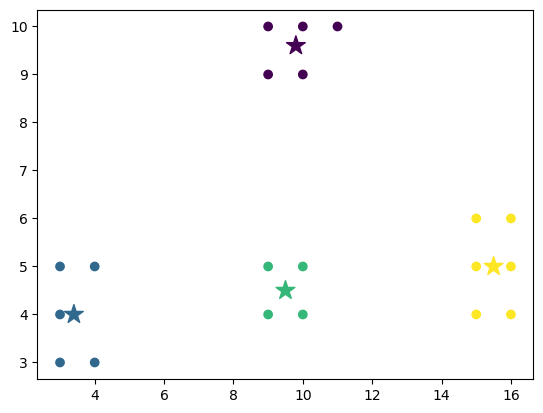

In [6]:
# visualizing the clusters
# you dont have to change anything here.
reduced_embeddings = np.array(data)


import matplotlib.pyplot as plt  # Import Matplotlib
# Scatter plot the data points with colors based on cluster labels
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=cluster_labels)

# Scatter plot the centroids with '*' markers and different colors
# The 's=200' parameter controls the size of the markers
plt.scatter(custom_kmeans.centroids[:, 0], custom_kmeans.centroids[:, 1], c=range(len(custom_kmeans.centroids)), marker="*", s=200)

# Display the plot
plt.show()



The K=4 seem to fit the data more that the k= [3,5,10] given.